`conda activate r_python`

In [ ]:
library(reshape2)
library(Seurat)
library(NMF)
library(ggplot2)
library(dplyr)
library(scales)
library(corrplot)
library(tidyverse)
library(ComplexHeatmap)
library(RColorBrewer)
library(jsonlite)
library(circlize)
source("scripts/custom_magma.R")
source("scripts/robust_nmf_programs.R")   

Loading required package: SeuratObject

Loading required package: sp

The legacy packages maptools, rgdal, and rgeos, underpinning this package
will retire shortly. Please refer to R-spatial evolution reports on
https://r-spatial.org/r/2023/05/15/evolution4.html for details.
This package is now running under evolution status 0 


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, saveRDS


Loading Seurat v5 beta version 
To maintain compatibility with previous workflows, new Seurat objects will use the previous object structure by default
To use new Seurat v5 assays: Please run: options(Seurat.object.assay.version = 'v5')

Loading required package: registry

Loading required package: rngtools

Loading required package: cluster

NMF - BioConductor layer [OK] | Shared memory capabilities [NO: bigmemory] | Cores 2/2

  To enable shared memory capabilities, try: install.extras('
NMF
')


Attaching package: ‘dplyr’


The following objec

In [ ]:
malignant <- readRDS('/projects/0/einf2548/cruiz/dmg/data/malignant_rna.rds')
malignant

An object of class Seurat 
19248 features across 291695 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

### Score cells for signature

### Using UCell

#### Metaprograms

In [ ]:
MP_list = readRDS('data/robust_NMF_programs_malignant_nomt_noribo.rds')

In [ ]:
malignant <- subset(malignant, cells = sample(Cells(malignant), 100000))
malignant

An object of class Seurat 
19248 features across 100000 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
for (i in 1:ncol(MP_list)) {
  gene_set <- as.data.frame(MP_list)[[i]]
  malignant <- UCell::AddModuleScore_UCell(
    obj = malignant,
    features = list(gene_set),
    ncores = 16,
    name = colnames(MP_list)[i]
  )
}

Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* C21ORF58”
Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* C4ORF47”
Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* C6ORF118,C8ORF34,C1ORF158”
Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* C11ORF96”


In [ ]:
MP_list

MP_1,MP_2,MP_3,MP_4,MP_5,MP_6,MP_7,MP_8,MP_9,MP_10,MP_11,MP_12,MP_13
DIAPH3,CA10,SPARCL1,FTL,BCAS1,VEGFA,GAP43,DNAH6,CD44,HSPH1,SLIT1,KCNH7,CHI3L1
RRM2,MMP16,CLU,FTH1,SIRT2,HILPDA,CAMK2D,MAP3K19,ACTN1,HSPE1,CHD7,SRRM4,GALNT15
TOP2A,PCDH15,DCLK1,EEF1A1,PKP4,SLC6A6,ITGA3,ARMC3,ELL2,USPL1,EGFR,STMN2,NNMT
CENPF,LHFPL3,AQP4,TMSB10,MBP,FAM162A,ADAMTS9,CFAP43,GAP43,CHORDC1,GLCCI1,ELAVL4,ABCA8
ASPM,NXPH1,EEPD1,GAPDH,BMPER,NDRG1,HIVEP3,DNAH9,HRH1,HSPD1,GRIK2,MYT1L,ANXA1
KNL1,SEZ6L,KCNN3,MIF,CDK18,PDK1,EMP1,C6ORF118,LPAR1,DNAJB1,HES6,NYAP2,C3
TPX2,DSCAM,ANOS1,TMSB4X,SHROOM4,INSIG2,GALR1,VWA3A,NAMPT,HSP90AA1,NKD1,RIT2,CP
BRIP1,PDGFRA,SLC4A4,B2M,ST18,SLC2A1,RASSF8,ZBBX,CLIC4,HSP90AB1,PAK3,RND3,MGST1
KIF14,FGF12,DAAM2,PTMA,MYRF,GBE1,RGS17,SPATA17,OSMR,HSPA1A,SEZ6L,CELF4,SPARCL1
NUSAP1,OPCML,APOE,ATP5F1E,PPP1R16B,AKAP12,SPOCD1,ADGB,SAMD4A,HSPA1B,BEST3,CNTNAP5,APOE


In [ ]:
# Extracting the scores
scores <- FetchData(
  malignant,
  vars = colnames(malignant@meta.data %>% 
    select(starts_with("signature")))
)
colnames(scores) <- gsub("^signature_1", "", colnames(scores))
scores

,MP_1,MP_2,MP_3,MP_4,MP_5,MP_6,MP_7,MP_8,MP_9,MP_10,MP_11,MP_12,MP_13
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BT042_pons_2_AGGCCACCATGGCCAC-1,0.04457333,0.31665333,0.15596667,0.03045333,0.04457333,0.17259333,0.13773333,0.03045333,0.2758667,0.06322000,0.11010667,0.04910000,0.11246667
BT042_pons_2_TCTATCAGTGGAGGTT-1,0.26788000,0.19537333,0.03303333,0.03303333,0.09983333,0.05248667,0.03303333,0.03303333,0.1252733,0.00000000,0.04973333,0.00000000,0.00000000
BT042_pons_2_GCAGCCAAGGACAAGA-1,0.00000000,0.06987333,0.12549333,0.00000000,0.00000000,0.00000000,0.00000000,0.41575333,0.0000000,0.00000000,0.03418000,0.03418000,0.00000000
BT042_pons_2_TGGCGTGCATACTGAC-1,0.00000000,0.00000000,0.13210000,0.00000000,0.03458000,0.08932000,0.12581333,0.07107333,0.1273467,0.03458000,0.05282667,0.00000000,0.12750000
BT042_pons_2_TTCTTGATCGCAAGAG-1,0.00000000,0.07067333,0.14652667,0.03444667,0.05256000,0.03444667,0.07237333,0.05256000,0.1121600,0.00000000,0.05256000,0.00000000,0.05256000
BT072_region_1_TTTGGTTTCGACACTA-1,0.00000000,0.14094667,0.29781333,0.11962667,0.04067333,0.06506667,0.47032000,0.00000000,0.4316267,0.33280667,0.08585333,0.07142667,0.27317333
BT072_region_1_CCATCACCAGCAATTC-1,0.01856667,0.14026667,0.36310000,0.05590667,0.06168000,0.07232667,0.25444000,0.07791333,0.4161600,0.09107333,0.07059333,0.03777333,0.27910667
BT072_region_1_CCCTCTCTCGAGTCTA-1,0.00000000,0.09336000,0.17576000,0.04269333,0.09319333,0.05742667,0.30007333,0.03754667,0.3272533,0.07110000,0.05606000,0.03004000,0.28338667
BT072_region_1_ACGTAACCAGGCTTGC-1,0.33312667,0.10129333,0.17216000,0.05449333,0.05098000,0.04864000,0.29054000,0.01850000,0.2339667,0.09926000,0.08492000,0.02798667,0.19734000


In [ ]:
# as suggested in https://doi.org/10.1038/s41588-023-01570-0
# Normalize scores by subtracting the mean score for each MP
normalized_scores <- apply(scores, 2, function(x) x - mean(x))
                           
# Function to determine the assignment of each cell
assign_to_MP <- function(score_row) {
  sorted_scores <- sort(score_row, decreasing = TRUE)
  top_score <- sorted_scores[1]
  second_score <- sorted_scores[2]

  if (second_score <= 0.85 * top_score) {
    return(names(sorted_scores)[1])
  } else {
    return("unresolved")
  }
}

# Apply the function to each row (cell)
cell_assignments <- apply(normalized_scores, 1, assign_to_MP)

In [ ]:
malignant$MP_Assignment <- cell_assignments

#### Curated signatures

In [ ]:
data <- fromJSON("../../data/malignant_signatures.json")
data

$global
$global$gb_MES2_like
 [1] "HILPDA"   "ADM"      "DDIT3"    "NDRG1"    "HERPUD1"  "DNAJB9"  
 [7] "TRIB3"    "ENO2"     "AKAP12"   "SQSTM1"   "MT1X"     "ATF3"    
[13] "NAMPT"    "NRN1"     "SLC2A1"   "BNIP3"    "LGALS3"   "INSIG2"  
[19] "IGFBP3"   "PPP1R15A" "VIM"      "PLOD2"    "GBE1"     "SLC2A3"  
[25] "FTL"      "WARS"     "ERO1L"    "XPOT"     "HSPA5"    "GDF15"   
[31] "ANXA2"    "EPAS1"    "LDHA"     "P4HA1"    "SERTAD1"  "PFKP"    
[37] "PGK1"     "EGLN3"    "SLC6A6"   "CA9"      "BNIP3L"   "RPL21"   
[43] "TRAM1"    "UFM1"     "ASNS"     "GOLT1B"   "ANGPTL4"  "SLC39A14"
[49] "CDKN1A"   "HSPA9"   

$global$gb_MES1_like
 [1] "CHI3L1"   "ANXA2"    "ANXA1"    "CD44"     "VIM"      "MT2A"    
 [7] "C1S"      "NAMPT"    "EFEMP1"   "C1R"      "SOD2"     "IFITM3"  
[13] "TIMP1"    "SPP1"     "A2M"      "S100A11"  "MT1X"     "S100A10" 
[19] "FN1"      "LGALS1"   "S100A16"  "CLIC1"    "MGST1"    "RCAN1"   
[25] "TAGLN2"   "NPC2"     "SERPING1" "C8orf4"   "EMP1"     "APOE"    
[31] "CTSB"     "C3"       "LGALS3"   "MT1E"     "EMP3"     "SERPINA3"
[37] "ACTN1"    "PRDX6"    "IGFBP7"   "SERPINE1" "PLP2"     "MGP"     
[43] "CLIC4"    "GFPT2"    "GSN"      "NNMT"     "TUBA1C"   "GJA1"    
[49] "TNFRSF1A" "WWTR1"   

$global$gb_AC_like
 [1] "CST3"    "S100B"   "SLC1A3"  "HEPN1"   "HOPX"    "MT3"     "SPARCL1"
 [8] "MLC1"    "GFAP"    "FABP7"   "BCAN"    "PON2"    "METTL7B" "SPARC"  
[15] "GATM"    "RAMP1"   "PMP2"    "AQP4"    "DBI"     "EDNRB"   "PTPRZ1" 
[22] "CLU"     "PMP22"   "ATP1A2"  "S100A16" "HEY1"    "PCDHGC3" "TTYH1"  
[29] "NDRG2"   "PRCP"    "ATP1B2"  "AGT"     "PLTP"    "GPM6B"   "F3"     
[36] "RAB31"   "PPAP2B"  "ANXA5"   "TSPAN7" 

$global$gb_OPC_like
 [1] "BCAN"    "PLP1"    "GPR17"   "FIBIN"   "LHFPL3"  "OLIG1"   "PSAT1"  
 [8] "SCRG1"   "OMG"     "APOD"    "SIRT2"   "TNR"     "THY1"    "PHYHIPL"
[15] "SOX2-OT" "NKAIN4"  "LPPR1"   "PTPRZ1"  "VCAN"    "DBI"     "PMP2"   
[22] "CNP"     "TNS3"    "LIMA1"   "CA10"    "PCDHGC3" "CNTN1"   "SCD5"   
[29] "P2RX7"   "CADM2"   "TTYH1"   "FGF12"   "TMEM206" "NEU4"    "FXYD6"  
[36] "RNF13"   "RTKN"    "GPM6B"   "LMF1"    "ALCAM"   "PGRMC1"  "HRASLS" 
[43] "BCAS1"   "RAB31"   "PLLP"    "FABP5"   "NLGN3"   "SERINC5" "EPB41L2"
[50] "GPR37L1"

$global$gb_NPC1_like
 [1] "DLL3"     "DLL1"     "SOX4"     "TUBB3"    "HES6"     "TAGLN3"  
 [7] "NEU4"     "MARCKSL1" "CD24"     "STMN1"    "TCF12"    "BEX1"    
[13] "OLIG1"    "MAP2"     "FXYD6"    "PTPRS"    "MLLT11"   "NPPA"    
[19] "BCAN"     "MEST"     "ASCL1"    "BTG2"     "DCX"      "NXPH1"   
[25] "HN1"      "PFN2"     "SCG3"     "MYT1"     "CHD7"     "GPR56"   
[31] "TUBA1A"   "PCBP4"    "ETV1"     "SHD"      "TNR"      "AMOTL2"  
[37] "DBN1"     "HIP1"     "ABAT"     "ELAVL4"   "LMF1"     "GRIK2"   
[43] "SERINC5"  "TSPAN13"  "ELMO1"    "GLCCI1"   "SEZ6L"    "LRRN1"   
[49] "SEZ6"     "SOX11"   

$global$gb_NPC2_like
 [1] "STMN2"        "CD24"         "RND3"         "HMP19"        "TUBB3"       
 [6] "MIAT"         "DCX"          "NSG1"         "ELAVL4"       "MLLT11"      
[11] "DLX6-AS1"     "SOX11"        "NREP"         "FNBP1L"       "TAGLN3"      
[16] "STMN4"        "DLX5"         "SOX4"         "MAP1B"        "RBFOX2"      
[21] "IGFBPL1"      "STMN1"        "HN1"          "TMEM161B-AS1" "DPYSL3"      
[26] "SEPT3"        "PKIA"         "ATP1B1"       "DYNC1I1"      "CD200"       
[31] "SNAP25"       "PAK3"         "NDRG4"        "KIF5A"        "UCHL1"       
[36] "ENO2"         "KIF5C"        "DDAH2"        "TUBB2A"       "LBH"         
[41] "LOC150568"    "TCF4"         "GNG3"         "NFIB"         "DPYSL5"      
[46] "CRABP1"       "DBN1"         "NFIX"         "CEP170"       "BLCAP"       

$global$gb_G1_S
 [1] "RRM2"     "PCNA"     "KIAA0101" "HIST1H4C" "MLF1IP"   "GMNN"    
 [7] "RNASEH2A" "MELK"     "CENPK"    "TK1"      "TMEM106C" "CDCA5"   
[13] "CKS1B"    "CDC45"    "MCM3"     "CENPM"    "AURKB"    "PKMYT1"  
[19] "MCM4"     "ASF1B"    "GINS2"    "MCM2"     "FEN1"     "RRM1"    
[25] "DUT"      "R

In [ ]:
signatures <- data$global
length(signatures)

[1] 89

In [ ]:
# Find the maximum length among the lists
max_length <- max(sapply(signatures, length))

# Pad the shorter lists with NA values to make them equal in length
padded_list <- lapply(signatures, function(x) {
  if (length(x) < max_length) {
    c(x, rep(NA, max_length - length(x)))
  } else {
    x
  }
})

# Convert the padded list to a data frame
nested_df <- as.data.frame(padded_list)

# Rename the columns with the list names
colnames(nested_df) <- names(signatures)

# Print the resulting data frame
nested_df

gb_MES2_like,gb_MES1_like,gb_AC_like,gb_OPC_like,gb_NPC1_like,gb_NPC2_like,gb_G1_S,gb_G2_M,gb_DevelopmentalGSC,gb_InjuryResponseGSC,⋯,gavish23_Oligo_normal,gavish23_NPC_OPC,gavish23_Glutathione,gavish23_Metal_response,chanoch22_MES_CORE_GENES,chanoch22_MES_OTHER,chanoch22_HYPOXIA,chanoch22_GLYCOLYSIS,chanoch22_APOPTOSIS,chanoch22_ASTROCYTE
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
HILPDA,CHI3L1,CST3,BCAN,DLL3,STMN2,RRM2,CCNB1,OCIAD2,PTPRZ1,⋯,APOD,BTG2,NAT8,MT1X,LGALS3,GLIPR1,MT1E,CHPF,SOD2,CLU
ADM,ANXA2,S100B,PLP1,DLL1,CD24,PCNA,CDC20,CAV1,TUBB2B,⋯,MBP,SOX6,ACSM2B,CAV1,S100A11,GADD45B,AKAP12,EGLN3,CASP1,APOE
DDIT3,ANXA1,SLC1A3,GPR17,SOX4,RND3,KIAA0101,CCNB2,TXN,S100B,⋯,PLA2G16,BAZ2B,LGALS2,MT1E,ANXA2,IGFBP3,ATF3,PKM,SQSTM1,GJA1
NDRG1,CD44,HEPN1,FIBIN,TUBB3,HMP19,HIST1H4C,PLK1,PLP2,C1orf61,⋯,PLP1,SOX4,AMN,C5ORF46,CHI3L1,LOX,CA12,PYGL,CASP4,SPARCL1
HERPUD1,VIM,HOPX,LHFPL3,HES6,TUBB3,MLF1IP,CCNA2,PFN1,PTN,⋯,PPP1R14A,DSEL,BBOX1,TGFBI,S100A10,MGP,CAV1,TXN,EMP1,AQP4
DNAJB9,MT2A,MT3,OLIG1,TAGLN3,MIAT,GMNN,CKAP2,S100A10,TTYH1,⋯,SEPP1,MXD4,KHK,CEBPB,TIMP1,PLAUR,CP,CHPF,DPYD,CST3
TRIB3,C1S,SPARCL1,PSAT1,NEU4,DCX,RNASEH2A,KNSTRN,PITX1,BAALC,⋯,TF,PNRC1,MIOX,CKB,ANXA1,SPP1,DDIT3,EGLN3,GPX1,F3
ENO2,NAMPT,MLC1,SCRG1,MARCKSL1,NSG1,MELK,RACGAP1,TMEM14B,TUBA1A,⋯,GSN,SOX5,SMIM24,EPB41L4A-AS1,CD44,TNC,GAPDH,PKM,GSN,GLUL
AKAP12,EFEMP1,GFAP,OMG,CD24,ELAVL4,CENPK,CDCA3,C12orf75,FEZ1,⋯,PTGDS,CHD7,AQP1,IGFBP5,CTSB,COL6A2,HSPA5,PYGL,HGF,HTRA1


In [ ]:
for (i in 1:ncol(nested_df)) {
  gene_set <- na.omit(as.data.frame(nested_df)[[i]])
  malignant <- UCell::AddModuleScore_UCell(
    obj = malignant,
    features = list(gene_set),
    ncores = 16,
    name = colnames(nested_df)[i]
  )
}

Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* ERO1L”
Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* C8orf4”
Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* PPAP2B”
Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* SOX2-OT,LPPR1,TMEM206,HRASLS”
Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* HN1,GPR56”
Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* HMP19,MIAT,DLX6-AS1,HN1,TMEM161B-AS1,SEPT3,LOC150568”
Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* KIAA0101,MLF1IP”
Warning message:
“The following genes were not found and will be
                        imputed to ex

In [ ]:
d_corrhtmp <- malignant@meta.data %>% 
    select(starts_with("signature")) %>% 
    scale() #Scale correlations
colnames(d_corrhtmp) <- gsub("^signature_1", "", colnames(d_corrhtmp))
d_corrhtmp

,MP_1,MP_2,MP_3,MP_4,MP_5,MP_6,MP_7,MP_8,MP_9,MP_10,⋯,gavish23_Oligo_Progenitor,gavish23_Oligo_normal,gavish23_NPC_OPC,gavish23_Glutathione,gavish23_Metal_response,chanoch22_MES_CORE_GENES,chanoch22_MES_OTHER,chanoch22_HYPOXIA,chanoch22_GLYCOLYSIS,chanoch22_APOPTOSIS
BT042_pons_2_AGGCCACCATGGCCAC-1,0.26987229,-0.1433725,-0.29380952,-0.69918473,-0.52675956,1.12917300,0.18744527,-0.13979991,1.20225605,-0.59196907,⋯,-0.70578754,-0.628514856,-1.04087205,0.33864219,0.112281900,-0.3864219,-0.25716258,-0.25576634,1.0407954,0.9902556
BT042_pons_2_TCTATCAGTGGAGGTT-1,3.91009202,-0.7368753,-1.05525301,-0.68666597,-0.01558784,-0.45196275,-0.97672573,-0.10913799,-0.20286521,-1.05623453,⋯,-0.08066140,-0.554763664,-1.42899417,-1.48646075,-0.001946063,-0.3256542,-0.97621376,-0.66000759,-0.5960714,-0.8961319
BT042_pons_2_GCAGCCAAGGACAAGA-1,-0.45673713,-1.3510293,-0.48255996,-0.84695144,-0.93907639,-1.14291977,-1.34402705,4.43928455,-1.37173651,-1.05623453,⋯,-1.51840867,-0.011825300,-1.76415107,-1.48646075,-0.868503025,-0.8377052,-0.93815936,-1.21644481,-0.5960714,0.3104410
BT042_pons_2_TGGCGTGCATACTGAC-1,-0.45673713,-1.6929654,-0.44163857,-0.84695144,-0.61920092,0.03292707,0.05490546,0.34294707,-0.18351984,-0.80229117,⋯,-1.07392213,-1.499045724,-1.53970014,0.31777194,0.834008713,0.1405462,1.61148553,-0.19607552,-0.5960714,-0.8961319
BT042_pons_2_TTCTTGATCGCAAGAG-1,-0.45673713,-1.3471144,-0.35228045,-0.67980815,-0.45288048,-0.68944906,-0.53929987,0.12292601,-0.32522005,-1.05623453,⋯,-1.07563598,-0.514362494,-2.54242130,-1.48646075,0.372400485,-0.2923654,-0.92930950,-0.62688075,-0.5960714,-0.8961319
BT072_region_1_TTTGGTTTCGACACTA-1,-0.45673713,-1.0032207,0.58478230,-0.26649483,-0.56283574,-0.28635423,3.88551358,-0.50172149,2.65558524,1.38778066,⋯,-0.85480664,-0.506930203,-0.52207347,-1.48646075,-0.397956535,2.4636970,3.41995458,0.67881692,-0.2270491,1.8998728
BT072_region_1_CCATCACCAGCAATTC-1,-0.15407377,-1.0065484,0.98916496,-0.57567920,-0.36851772,-0.19078047,1.48511974,0.42423681,2.51127247,-0.38742398,⋯,-0.89336822,-0.456047598,-0.60354728,-0.33407538,-0.089813727,1.0220716,0.77141249,0.50021323,-0.5960714,1.8610637
BT072_region_1_CCCTCTCTCGAGTCTA-1,-0.45673713,-1.2360936,-0.17121051,-0.63979339,-0.07700985,-0.38693047,1.99252187,-0.05549943,1.68172281,-0.53410112,⋯,-0.91376302,-1.499045724,-0.81171792,0.14907079,-0.962582024,2.1381889,1.19753329,-0.69954104,-0.5960714,1.6822798
BT072_region_1_ACGTAACCAGGCTTGC-1,4.97370650,-1.1972706,-0.19350875,-0.58253702,-0.46749596,-0.50260192,1.88651967,-0.28185888,0.81130527,-0.32730398,⋯,-0.85215017,-0.467481891,-0.48915111,-1.48646075,-0.717158548,1.0528481,1.45705546,-0.14263505,-0.5960714,1.5183220
BT072_region_1_CTACTATTCCGAACGC-1,-0.13136043,-0.7518173,0.67632895,-0.52647754,0.46431786,-0.11363691,1.48489735,-0.11460484,2.88399754,-0.66060771,⋯,-0.97151970,-0.216308580,-0.33951715,-0.53964730,-0.971823278,1.4932967,2.18407152,0.42177137,0.5301358,2.6490207


In [ ]:
dTest_corrhtmp <- cor.mtest(d_corrhtmp, method = "pearson", conf.level=0.95)
d_corrhtmp<- cor(d_corrhtmp, method = "pearson")
d_corrhtmp

,MP_1,MP_2,MP_3,MP_4,MP_5,MP_6,MP_7,MP_8,MP_9,MP_10,⋯,gavish23_Oligo_Progenitor,gavish23_Oligo_normal,gavish23_NPC_OPC,gavish23_Glutathione,gavish23_Metal_response,chanoch22_MES_CORE_GENES,chanoch22_MES_OTHER,chanoch22_HYPOXIA,chanoch22_GLYCOLYSIS,chanoch22_APOPTOSIS
MP_1,1.000000000,0.149131117,-0.171467378,0.01294895,-0.060892536,-0.0425886718,-0.05535187,-0.09425041,-0.109758411,-0.004255937,⋯,0.02838901,-0.0672766397,0.09409614,-0.053096774,-0.036447879,-0.08741288,-0.083163157,-0.06367296,-0.028848822,-0.08172378
MP_2,0.149131117,1.000000000,-0.349013936,-0.21363491,0.347083089,-0.2318926800,-0.19445071,-0.20769728,-0.319659152,-0.260613038,⋯,0.72400566,0.1639232315,0.80152274,-0.194298628,-0.230481185,-0.49456825,-0.346219873,-0.40107910,-0.228046798,-0.30774940
MP_3,-0.171467378,-0.349013936,1.000000000,-0.18546576,-0.157567337,0.0416619168,0.18166691,0.34604976,0.540677137,0.062750516,⋯,-0.38917036,-0.1085605997,-0.11722385,0.318145633,0.072877950,0.22304868,0.307083064,0.05846994,-0.065479960,0.24865698
MP_4,0.012948952,-0.213634909,-0.185465762,1.00000000,-0.146044935,0.1263321798,-0.11909274,-0.07936154,-0.125518447,0.257734538,⋯,0.16952529,0.3124713953,-0.24151211,0.266838191,0.737181059,0.50138548,0.236688104,0.42208935,0.539828117,0.04557926
MP_5,-0.060892536,0.347083089,-0.157567337,-0.14604493,1.000000000,-0.1165161565,-0.15948130,-0.08304104,-0.187618354,-0.063305275,⋯,0.54793413,0.6040543708,0.31178101,-0.197402784,-0.117944460,-0.24940092,-0.172082647,-0.23143414,-0.141108513,-0.12227168
MP_6,-0.042588672,-0.231892680,0.041661917,0.12633218,-0.116516156,1.0000000000,0.32937252,0.04001182,0.342117417,0.369265590,⋯,-0.20436722,-0.0130323343,-0.14779496,0.129014131,0.279989173,0.33604828,0.432025238,0.78272853,0.333522894,0.28658398
MP_7,-0.055351870,-0.194450711,0.181666913,-0.11909274,-0.159481299,0.3293725155,1.00000000,0.02131988,0.642764682,0.287561689,⋯,-0.36972960,-0.1989835559,-0.11510597,0.141949477,0.008548662,0.42225120,0.581837412,0.36499705,0.058794291,0.49066678
MP_8,-0.094250406,-0.207697278,0.346049764,-0.07936154,-0.083041042,0.0400118235,0.02131988,1.00000000,0.234442440,0.061060900,⋯,-0.23437417,-0.0280913369,-0.08996559,0.142595936,0.025286043,0.18472164,0.082530348,0.06881011,-0.002494297,0.17026055
MP_9,-0.109758411,-0.319659152,0.540677137,-0.12551845,-0.187618354,0.3421174174,0.64276468,0.23444244,1.000000000,0.313574418,⋯,-0.44733373,-0.1450638111,-0.13991089,0.222028535,0.090311321,0.49315005,0.612219864,0.37303951,0.048820215,0.59507879
MP_10,-0.004255937,-0.260613038,0.062750516,0.25773454,-0.063305275,0.3692655897,0.28756169,0.06106090,0.313574418,1.000000000,⋯,-0.21544965,0.0702613759,-0.05274448,0.152049377,0.229551134,0.42679763,0.366036344,0.50249191,0.175301846,0.34519820


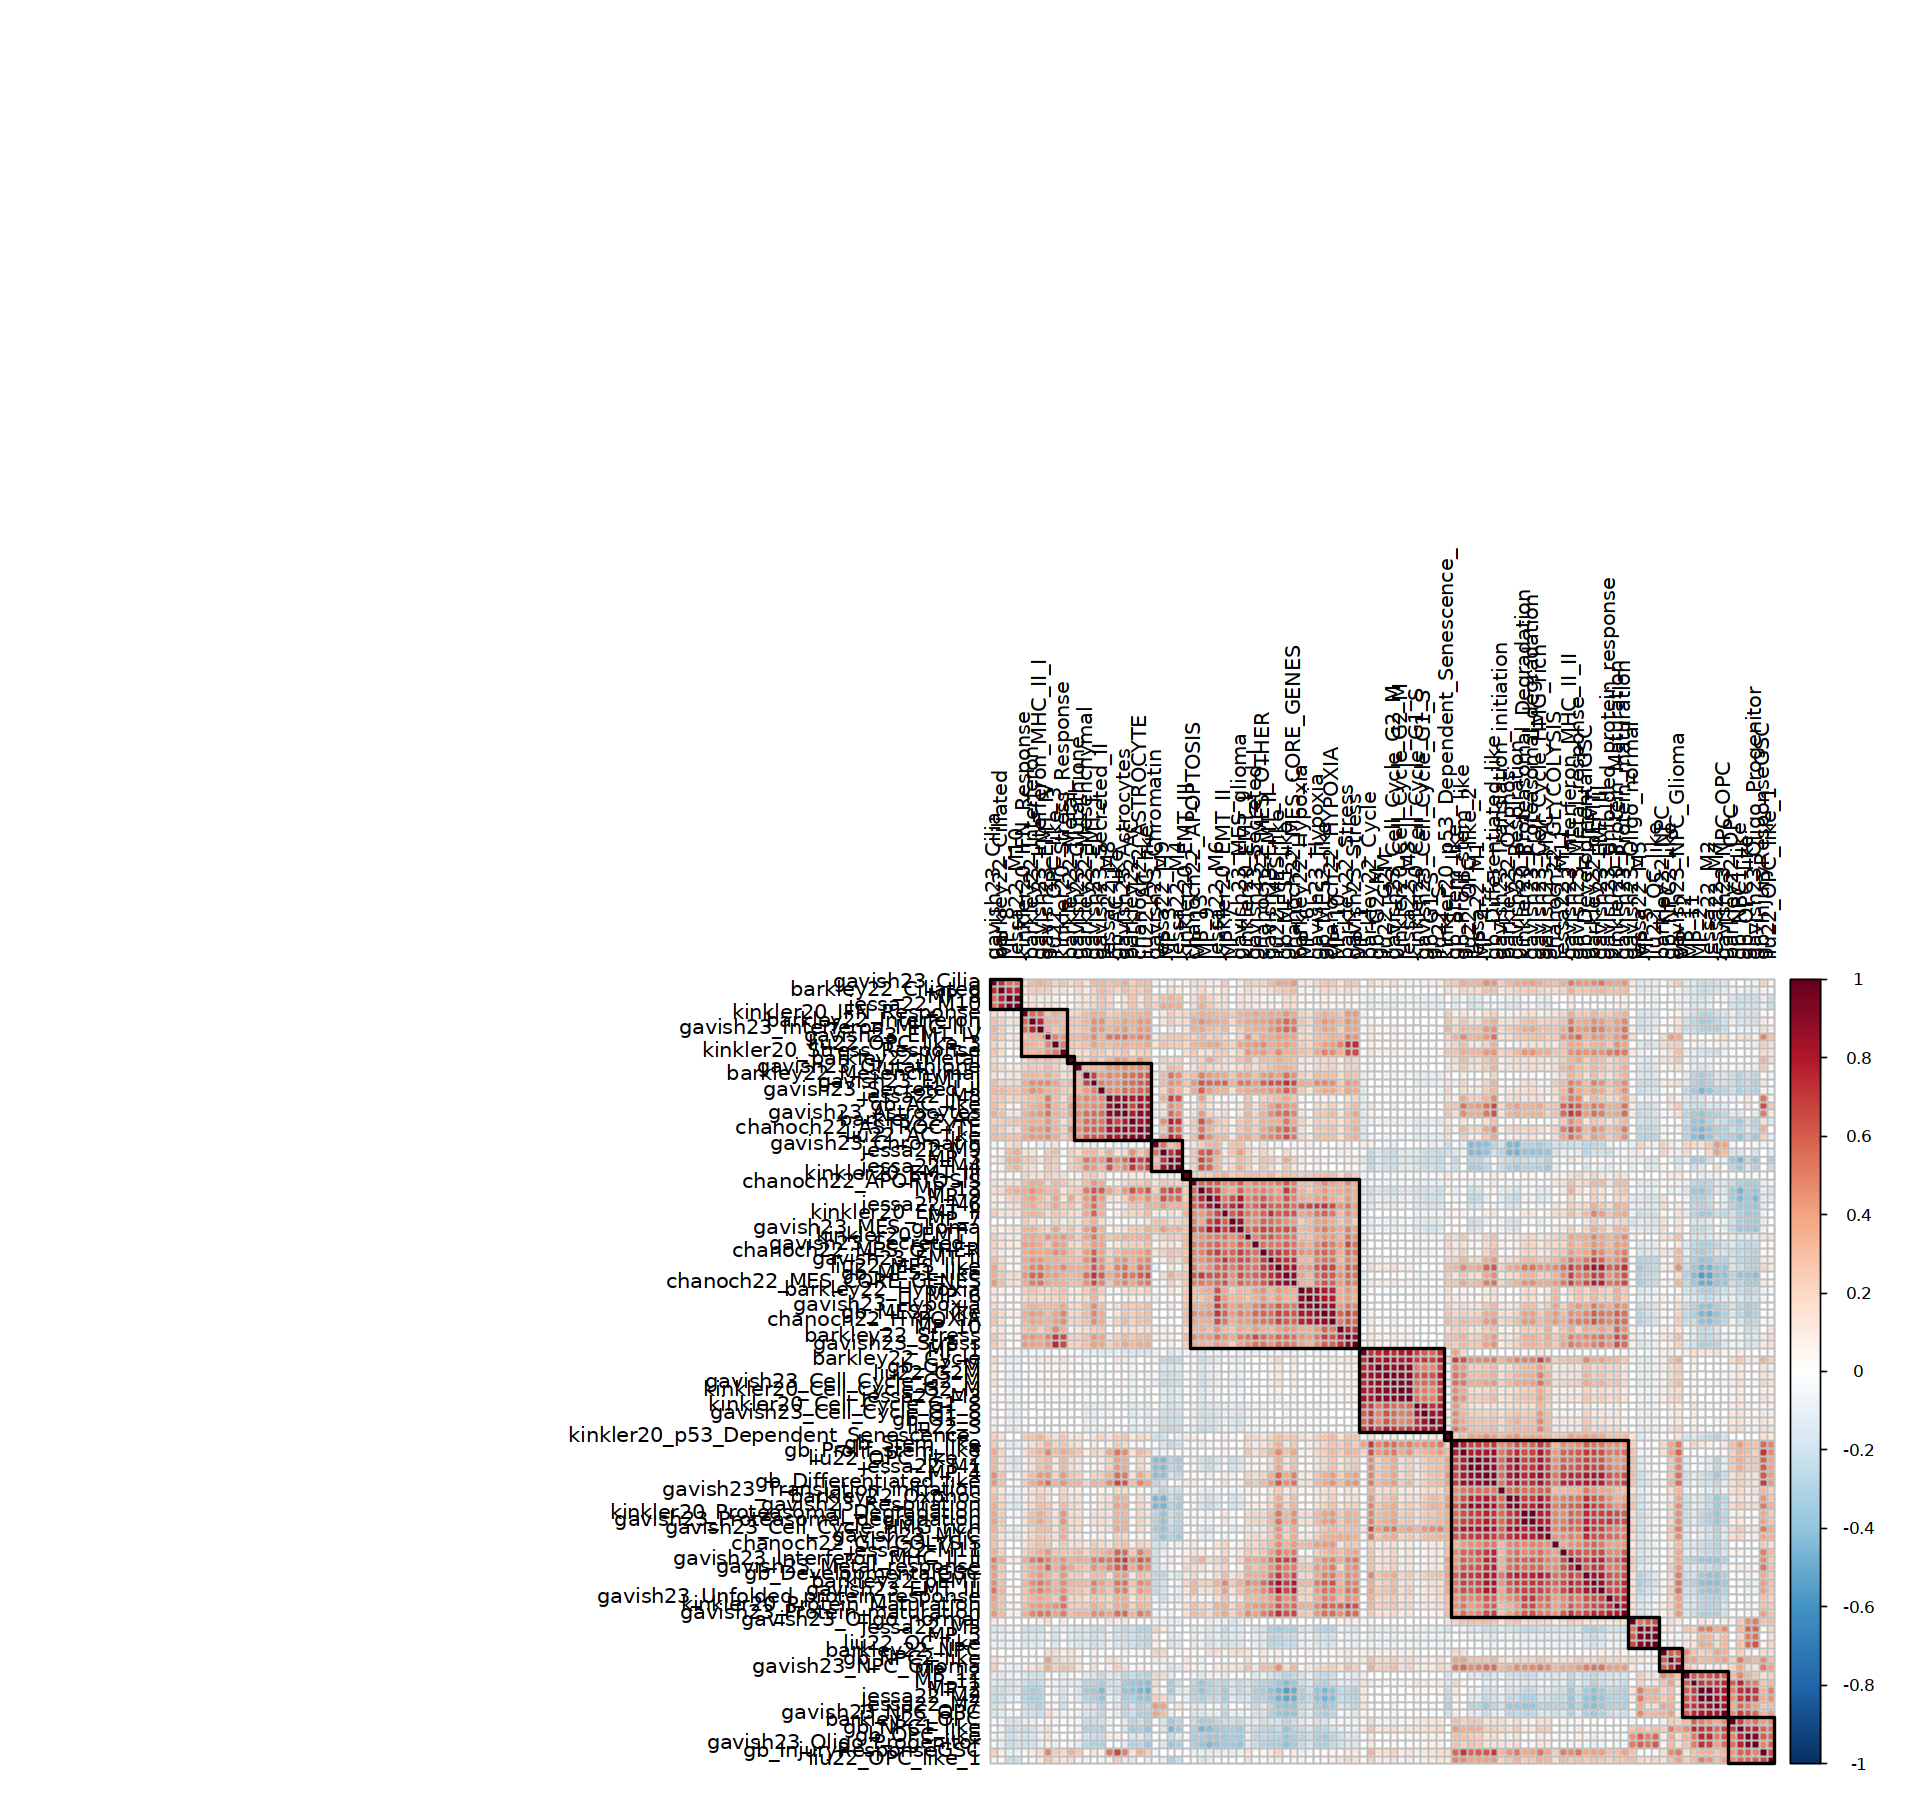

In [ ]:
#Plot correlation matrix
options(repr.plot.height = 15, repr.plot.width = 16)
corrplot::corrplot(d_corrhtmp, type = "full", 
    order = "hclust", hclust.method = "complete",
    tl.col = "black", tl.srt = 90,
    addrect = 14, rect.col = "black", rect.lwd = 2,
    col = rev(corrplot::COL2("RdBu")),
    p.mat = dTest_corrhtmp$p, sig.level = 0.05, insig = "blank"
    )

In [ ]:
pdf('figures/correlation_heatmap_malignant_MP_and_signatures_nomito_noribo.pdf', width = 15, height = 15)
corrplot::corrplot(d_corrhtmp, type = "full", 
    order = "hclust", hclust.method = "complete",
    tl.col = "black", tl.srt = 90,
    addrect = 14, rect.col = "black", rect.lwd = 2,
    col = rev(corrplot::COL2("RdBu")),
    p.mat = dTest_corrhtmp$p, sig.level = 0.05, insig = "blank"
    )
dev.off()

png 
  2